In [ ]:
# This code tries to predict the sensible load in Room 1121 using an autoregressive model.

import numpy as np
import pandas as pd
from src import df_sanitizer
import sktime
from matplotlib import pyplot
import matplotlib as plt
import seaborn
import datetime
import statsmodels

# Pulls and sanitizes the data for Room 1121.
# Calculates the sensible load from recorded variables.

df1121 = pd.read_csv(r"Data/Rm1121 - VMA13.csv")
df1121 = df_sanitizer.sanitize_df(df1121)
df1121_sensible_load = 1.08 * df1121["supply air flow"] * (df1121["zone temp"] - df1121["supply air temp"])
df1121_sensible_load.head()

ts
2022-11-04 00:15:00+00:00    3702.334110
2022-11-04 00:30:00+00:00   -7940.642403
2022-11-04 00:45:00+00:00   -8025.785816
2022-11-04 01:00:00+00:00   -7842.391521
2022-11-04 01:15:00+00:00    4625.440292
dtype: float64

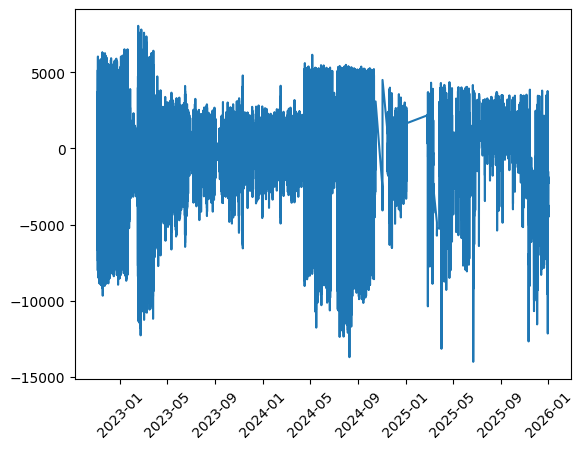

In [ ]:
# Plots sensible load recorded every 15 minutes from November 4, 2022 to January 1, 2026.

pyplot.plot(df1121_sensible_load)
pyplot.xticks(rotation=45)
pyplot.show()

In [3]:
# Performs a train-test split with 36% of the data.

from sktime.split import temporal_train_test_split
train, test = temporal_train_test_split(df1121_sensible_load, test_size=36)

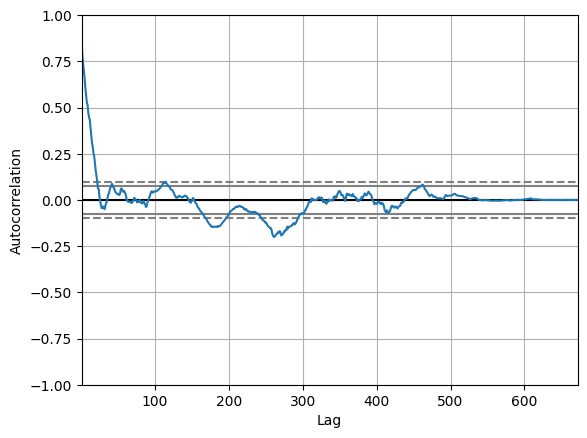

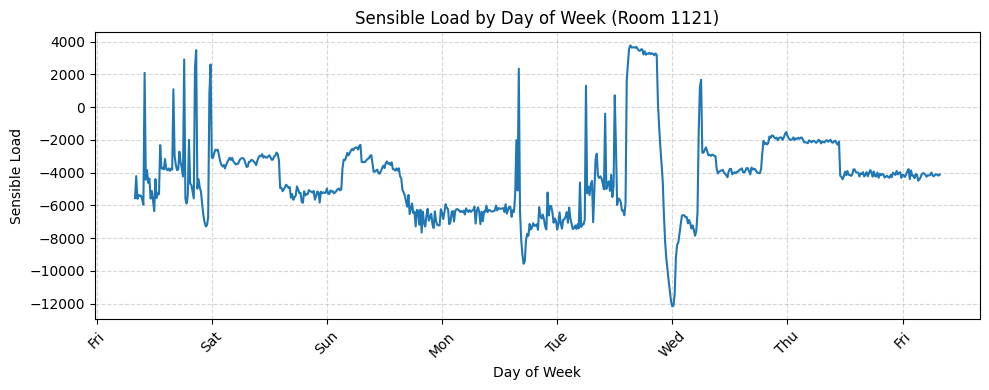

In [ ]:
# Creates autocorrelation plot of the last 7 days of the training data to check for autocorrelation in the data.

from pandas.plotting import autocorrelation_plot

# Every day has 96 data points (15 minutes per data point), so 7 days has 96*7 data points.

# Just uses the first 96*7 data points to make the plot easier to read

intervals = 96*7

autocorrelation_plot(train[-intervals:]) # autocorrelation plot of the last 7 days of the training data
# Overstates correlation between points because it also uses correlation of points between them

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df1121_sensible_load[-intervals:].index, df1121_sensible_load[-intervals:].values)

# One major tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Show day of week (Mon, Tue, ...)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a'))

# Rotate labels to prevent overlapping
plt.xticks(rotation=45)

# Add gridlines for readability
ax.grid(True, linestyle='--', alpha=0.5)

# Add labels and title
ax.set_xlabel('Day of Week')
ax.set_ylabel('Sensible Load')
ax.set_title('Sensible Load by Day of Week (Room 1121)')

plt.tight_layout()
plt.show()

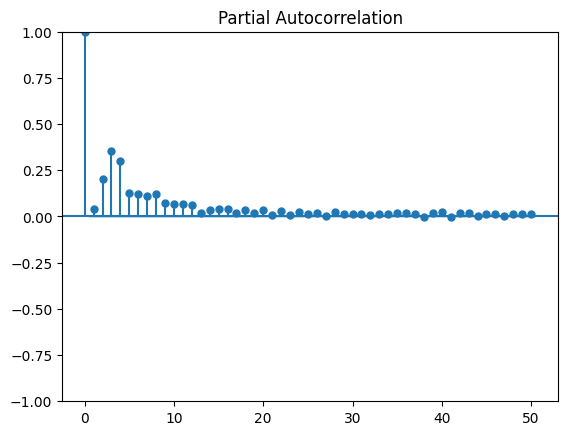

In [ ]:
# Partial autocorrelation plot of the last 7 days of the training data to check for autocorrelation in the data.
# Partial autocorrelation plot is better for checking for autocorrelation because it only uses the correlation of points between them,
# not the correlation of points between points between them.

from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(train)
pyplot.show()

In [ ]:
# There is a lot of correlation for lags up to 15.
# This records data about the model based on the previous 15 data points, which is a little less than 4 hours of data.
# Note that thee autocorrelation chart only implies that a given data point is correlated with the previous 6 values.

from statsmodels.tsa.ar_model import AutoReg

params = AutoReg(train, lags = 15, trend="ct", seasonal = False, period = 96)
res = params.fit()
res.summary()

/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                81214
Model:                    AutoReg(15)   Log Likelihood             -753532.704
Method:               Conditional MLE   S.D. of innovations           2594.464
Date:                Thu, 05 Mar 2026   AIC                        1507101.408
Time:                        14:12:17   BIC                        1507268.892
Sample:                            15   HQIC                       1507152.716
                                81214                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1968     18.215     -0.066      0.948     -36.898      34.504
trend         -0.0011      0.000     -2.880      0.004      -0.002      -0.000
y.L1          -0.2566      0.004    -73.178      0.000      -0.263      -0.250
y.L2          -0.0213      0.004     -5.897      0.000      -0.028      -0.014
y.L3           0.2130      0.004     58.905      0.000       0.206       0.220
y.L4           0.2029      0.004     55.047      0.000       0.196       0.210
y.L5           0.0672      0.004     17.948      0.000       0.060       0.075
y.L6           0.0848      0.004     22.643      0.000       0.077       0.092
y.L7           0.0910      0.004     24.259      0.000       0.084       0.098
y.L8           0.1006      0.004     26.828      0.000       0.093       0.108
y.L9           0.0647      0.004     17.258      0.000       0.057       0.072
y.L10          0.0667      0.004     17.810      0.000       0.059       0.074
y.L11          0.0662      0.004     17.670      0.000       0.059       0.074
y.L12          0.0576      0.004     15.619      0.000       0.050       0.065
y.L13          0.0313      0.004      8.670      0.000       0.024       0.038
y.L14          0.0479      0.004     13.243      0.000       0.041       0.055
y.L15          0.0413      0.004     11.770      0.000       0.034       0.048
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             1.0170           -0.0000j            1.0170           -0.0000
AR.2             1.0833           -0.5792j            1.2285           -0.0781
AR.3             1.0833           +0.5792j            1.2285            0.0781
AR.4             0.7885           -1.0038j            1.2765           -0.1440
AR.5             0.7885           +1.0038j            1.2765            0.1440
AR.6             0.2942           -1.2419j            1.2763           -0.2130
AR.7             0.2942           +1.2419j            1.2763            0.2130
AR.8            -0.2130           -1.1613j            1.1807           -0.2789
AR.9            -0.2130           +1.1613j            1.1807            0.2789
AR.10           -0.6692           -1.0262j            1.2252           -0.3420
AR.11           -0.6692           +1.0262j            1.2252            0.3420
AR.12           -1.0706           -0.7032j            1.2808           -0.4075
AR.13           -1.0706           +0.7032j            1.2808            0.4075
AR.14           -1.3020           -0.1957j            1.3166           -0.4763
AR.15           -1.3020           +0.1957j            1.3166            0.4763
------------------------------------------------------------------------------
"""

In [ ]:
# Optimizes the number of lags to use based on the AIC.

from statsmodels.tsa.ar_model import ar_select_order

select = ar_select_order(train, 200, ic="aic", trend="ct", seasonal=True, period=96)
print(select.ar_lags)

/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198]


/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
# The model performs better with a seasonal component.

model = AutoReg(train, lags=range(1,199), trend="ct", seasonal = True, period = 96)
res = model.fit()
print("AIC: {0} \nBIC: {1} \nHQIC: {2}".format(res.aic, res.bic, res.hqic))

/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


AIC: 1501655.5238792696 
BIC: 1504409.0348549932 
HQIC: 1502499.132915934


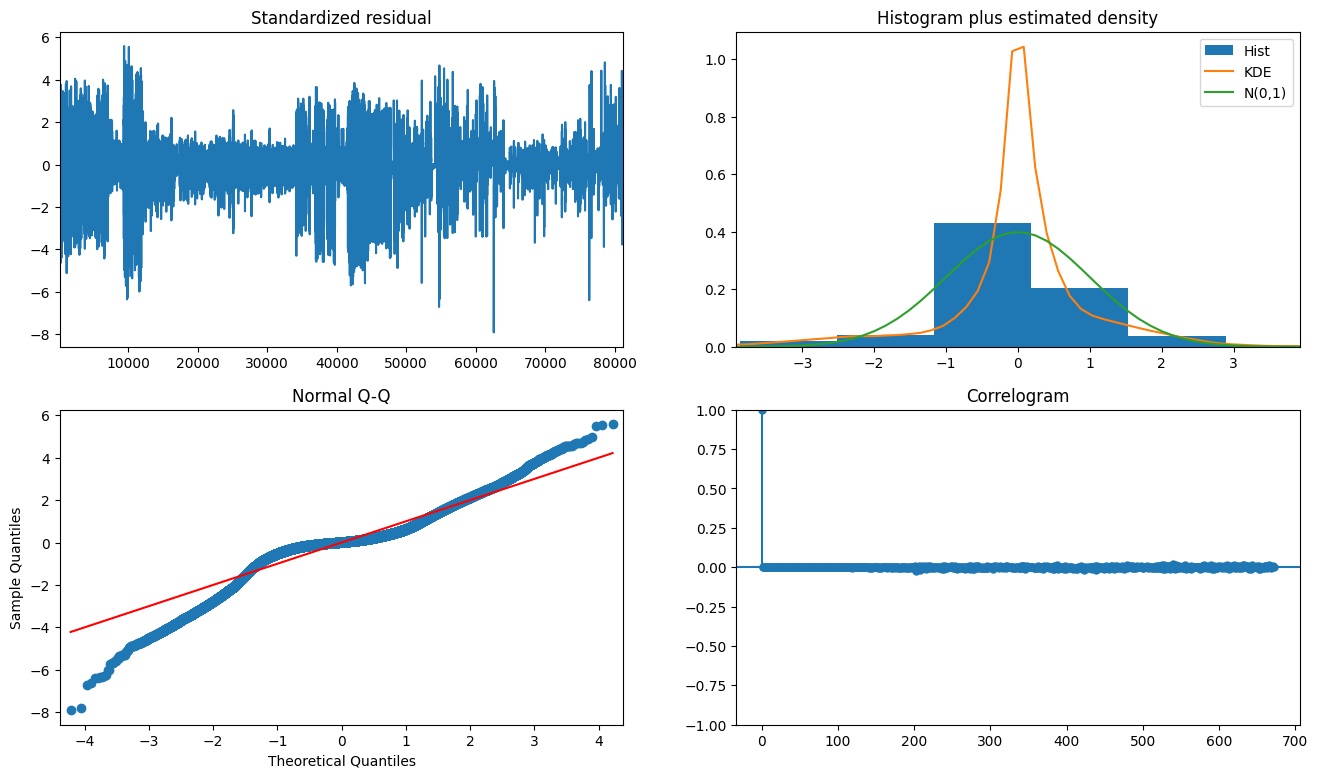

In [ ]:
# Plots diagnostics of the model to check for autocorrelation in the residuals.

fig = pyplot.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig, lags=96*7)

In [ ]:
# Makes and tests the model.

testing = pd.concat([train,test])
ar24_predictions = []

for i in range(len(train), len(train) + len(test)):
    updated_res = res.apply(testing[:i])
    ar24_predictions.append(updated_res.forecast(1).iloc[0])

/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/envs/skysparkConnect/lib/python3.14/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, Ra

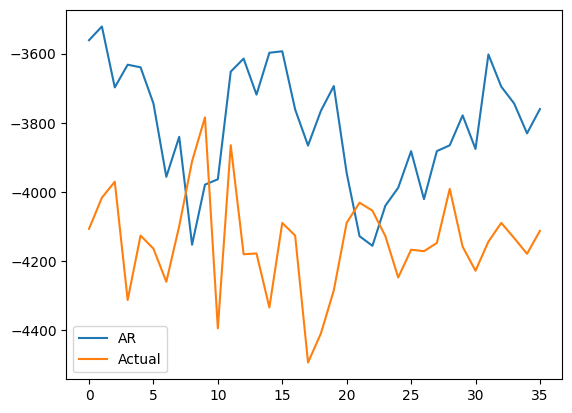

In [ ]:
# The model's predictions compared with actual events.
# Clearly the model is not very good at predicting the actual sensible load, but it does capture some of the trends in the data. 

predictions = pd.DataFrame({
    "AR": ar24_predictions,
    "Actual": test.values,
})
_, ax = pyplot.subplots()
ax = predictions.plot(ax=ax)

In [ ]:
# Metrics for evaluating the model's performance.

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(predictions['AR'], test.values))
print('Test RMSE: %.3f' % rmse)

# Pearson-Spearman correlation
import scipy.stats as stats
pearson_corr, _ = stats.pearsonr(predictions['AR'], test.values)
spearman_corr, _ = stats.spearmanr(predictions['AR'], test.values)
print('Pearson correlation: %.3f' % pearson_corr)
print('Spearman correlation: %.3f' % spearman_corr)

Test RMSE: 408.437
Pearson correlation: -0.111
Spearman correlation: -0.046
